In [16]:
# Problem: Robust Linear Regression with Uncertain Features
#
# A data scientist is training a linear model y = Xβ, but the feature matrix X is noisy.
# Instead of assuming X is exact, each row x_i can vary within an uncertainty radius delta.
#
# The goal is to find coefficients β that minimize the worst-case residual error.
#
# Variables:
#   β ∈ R^n : model coefficients
#   t ∈ R   : upper bound on the worst-case error
#
# Mathematical Model:
#   Minimize: t
#   Subject to:
#       || y[i] - X[i]β ||_2 + delta * ||β||_2 ≤ t   for all i = 1,...,m
#
# This is formulated as a Second-Order Cone Program (SOCP).


import cvxpy as cp
import numpy as np

m = 30
n = 10

X = np.random.randn(m, n)
y = np.random.randn(m)

delta = 0.1  # Uncertainty radius

beta = cp.Variable(n)
t = cp.Variable()

# SOCP Constraint: Residual + Uncertainty Penalty <= t
constraints = [
    cp.norm(y[i] - X[i] @ beta) + delta * cp.norm(beta, 2) <= t
    for i in range(m)
]

prob = cp.Problem(cp.Minimize(t), constraints)
prob.solve()

print(f"Robust Beta: {np.round(beta.value, 4)}")

Robust Beta: [ 0.2295 -0.1546  0.6102 -0.3923 -0.3477 -0.0724 -0.5066 -0.2291  0.5081
  0.0199]


In [17]:
#SDP
#2x2 Matrix version

# Problem: Matrix Completion with Minimum Complexity (2×2 Case)
#
# A data scientist is working with a partially known rating matrix.
# The goal is to estimate the missing entries by finding a matrix X (2×2) such that:
#
# 1. The matrix matches the known values:
#    - X[0, 0] = 5
#    - X[1, 1] = 3
#
# 2. The matrix has the simplest possible structure.
#    This is achieved by minimizing the trace of X (sum of diagonal elements).
#
# 3. The matrix must be positive semidefinite (X >> 0).
#
# Mathematical Model:
#   Minimize: trace(X)
#   Subject to:
#       X[0,0] = 5
#       X[1,1] = 3
#       X is positive semidefinite


import cvxpy as cp

# Define a 2x2 positive semidefinite matrix
X = cp.Variable((2, 2), PSD=True)  # Forces X >> 0

# Objective: minimize trace
objective = cp.Minimize(cp.trace(X))

# Constraints
constraints = [
    X[0, 0] == 5,
    X[1, 1] == 3
]

# Solve problem
prob = cp.Problem(objective, constraints)
prob.solve()

print(f"Optimal Matrix:\n{X.value}")

Optimal Matrix:
[[5.00000009 0.        ]
 [0.         3.00000006]]


In [18]:
#SDP
#3x3 Matrix version

# Problem: Matrix Completion with Additional Constraints (3×3 Case)
#
# A streaming service wants to predict missing ratings from a partially observed matrix.
# The goal is to find a matrix X (3×3) such that:
#
# 1. The matrix matches the known entries:
#    - X[0, 0] = 5
#    - X[1, 1] = 3
#    - X[0, 2] = 1
#
# 2. The matrix has the lowest possible complexity.
#    This is enforced by minimizing the trace of X.
#
# 3. The matrix must be positive semidefinite (X >> 0).
#
# Mathematical Model:
#   Minimize: trace(X)
#   Subject to:
#       X[0,0] = 5
#       X[1,1] = 3
#       X[0,2] = 1
#       X is positive semidefinite

import cvxpy as cp

# Define a 3x3 positive semidefinite matrix
X = cp.Variable((3, 3), PSD=True)  # Forces X >> 0

# Objective: minimize trace
objective = cp.Minimize(cp.trace(X))

# Constraints
constraints = [
    X[0, 0] == 5,
    X[1, 1] == 3,
    X[0, 2] == 1
]

# Solve problem
prob = cp.Problem(objective, constraints)
prob.solve()

print(f"Optimal Matrix:\n{X.value}")

Optimal Matrix:
[[4.99999978e+00 2.18223740e-15 9.99999897e-01]
 [2.18223740e-15 3.00000005e+00 1.19938378e-15]
 [9.99999897e-01 1.19938378e-15 2.00008434e-01]]


In [19]:
import numpy as np

# Example: minimize f(w) = (1/2n)||Xw - y||^2

def sgd(X, y, lr=0.01, epochs=100):
    m, n = X.shape
    w = np.zeros(n)

    for epoch in range(epochs):
        for i in range(m):
            xi = X[i]
            yi = y[i]

            gradient = (xi @ w - yi) * xi
            w = w - lr * gradient

    return w


# Test
X = np.random.randn(100, 5)
y = np.random.randn(100)
w = sgd(X, y)

print("SGD Solution:", w)

SGD Solution: [ 0.03734374  0.02854564 -0.12168109 -0.02193839 -0.05187113]


In [20]:
import numpy as np

# Projection onto L2 ball
def project(w, R=1.0):
    if np.linalg.norm(w) > R:
        return R * w / np.linalg.norm(w)
    return w

def pgd(X, y, lr=0.01, epochs=100, R=1.0):
    m, n = X.shape
    w = np.zeros(n)

    for _ in range(epochs):
        gradient = X.T @ (X @ w - y) / m
        w = w - lr * gradient
        w = project(w, R)  # projection step

    return w


# Test
w = pgd(X, y)
print("PGD Solution:", w)


PGD Solution: [ 0.05539057 -0.00705885 -0.07754126 -0.04237042 -0.02150176]


In [21]:
import numpy as np

def agd(X, y, lr=0.01, epochs=100):
    m, n = X.shape
    w = np.zeros(n)
    v = np.zeros(n)
    gamma = 0.9  # momentum

    for _ in range(epochs):
        gradient = X.T @ (X @ v - y) / m
        w_new = v - lr * gradient
        v = w_new + gamma * (w_new - w)
        w = w_new

    return w


# Test
w = agd(X, y)
print("AGD Solution:", w)

AGD Solution: [ 0.10046492 -0.02119352 -0.1420793  -0.06288144 -0.02586688]


In [22]:
import numpy as np

def coordinate_descent(X, y, epochs=100):
    m, n = X.shape
    w = np.zeros(n)

    for _ in range(epochs):
        for j in range(n):
            residual = X @ w - y
            rho = X[:, j] @ (y - (residual - w[j] * X[:, j]))
            z = np.sum(X[:, j] ** 2)

            if z != 0:
                w[j] = rho / z

    return w


# Test
w = coordinate_descent(X, y)
print("Coordinate Descent Solution:", w)


Coordinate Descent Solution: [ 0.20167308 -0.0422811  -0.2846832  -0.1258912  -0.05135979]


In [23]:
import numpy as np

# Linear minimization oracle for L2 ball
def lmo(grad, R=1.0):
    return -R * grad / np.linalg.norm(grad)

def frank_wolfe(X, y, epochs=100, R=1.0):
    m, n = X.shape
    w = np.zeros(n)

    for k in range(epochs):
        gradient = X.T @ (X @ w - y) / m

        s = lmo(gradient, R)   # direction from oracle
        gamma = 2 / (k + 2)    # step size

        w = (1 - gamma) * w + gamma * s

    return w


# Test
w = frank_wolfe(X, y)
print("Frank-Wolfe Solution:", w)

Frank-Wolfe Solution: [ 0.10060849 -0.01533301 -0.14248491 -0.05417485 -0.02895696]


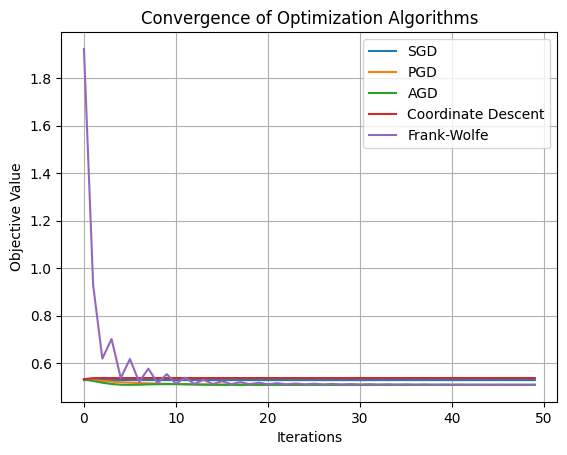

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
np.random.seed(0)
m, n = 100, 5
X = np.random.randn(m, n)
y = np.random.randn(m)

# Objective function
def f(w):
    return 0.5 * np.linalg.norm(X @ w - y) ** 2 / m

# Gradient
def grad(w):
    return X.T @ (X @ w - y) / m


# -------------------------------
# 1. SGD
# -------------------------------
def sgd(epochs=50, lr=0.05):
    w = np.zeros(n)
    history = []

    for _ in range(epochs):
        for i in range(m):
            g = (X[i] @ w - y[i]) * X[i]
            w -= lr * g
        history.append(f(w))

    return history


# -------------------------------
# 2. Projected GD (L2 ball)
# -------------------------------
def project(w, R=2):
    norm = np.linalg.norm(w)
    return w if norm <= R else R * w / norm

def pgd(epochs=50, lr=0.1):
    w = np.zeros(n)
    history = []

    for _ in range(epochs):
        w -= lr * grad(w)
        w = project(w)
        history.append(f(w))

    return history


# -------------------------------
# 3. Accelerated GD (Nesterov)
# -------------------------------
def agd(epochs=50, lr=0.1):
    w = np.zeros(n)
    v = np.zeros(n)
    gamma = 0.9
    history = []

    for _ in range(epochs):
        w_new = v - lr * grad(v)
        v = w_new + gamma * (w_new - w)
        w = w_new
        history.append(f(w))

    return history


# -------------------------------
# 4. Coordinate Descent
# -------------------------------
def coordinate_descent(epochs=50):
    w = np.zeros(n)
    history = []

    for _ in range(epochs):
        for j in range(n):
            residual = X @ w - y
            rho = X[:, j] @ (y - (residual - w[j] * X[:, j]))
            z = np.sum(X[:, j] ** 2)
            if z != 0:
                w[j] = rho / z
        history.append(f(w))

    return history


# -------------------------------
# 5. Frank-Wolfe (Conditional Gradient)
# -------------------------------
def lmo(g, R=2):
    return -R * g / np.linalg.norm(g)

def frank_wolfe(epochs=50):
    w = np.zeros(n)
    history = []

    for k in range(epochs):
        g = grad(w)
        s = lmo(g)
        gamma = 2 / (k + 2)
        w = (1 - gamma) * w + gamma * s
        history.append(f(w))

    return history


# Run all algorithms
hist_sgd = sgd()
hist_pgd = pgd()
hist_agd = agd()
hist_cd = coordinate_descent()
hist_fw = frank_wolfe()

# -------------------------------
# Plot convergence
# -------------------------------
plt.plot(hist_sgd, label="SGD")
plt.plot(hist_pgd, label="PGD")
plt.plot(hist_agd, label="AGD")
plt.plot(hist_cd, label="Coordinate Descent")
plt.plot(hist_fw, label="Frank-Wolfe")

plt.xlabel("Iterations")
plt.ylabel("Objective Value")
plt.title("Convergence of Optimization Algorithms")
plt.legend()
plt.grid()

plt.show()

In [25]:
# =========================================
# FULL SCRIPT: LPP + QP (APPLICATION BASED)
# =========================================

import cvxpy as cp
import numpy as np


# =========================================
# PART 1: LINEAR PROGRAMMING (LPP)
# =========================================
# Problem: Production Planning
#
# A factory produces two products:
#   Product A profit = 3
#   Product B profit = 5
#
# Constraints:
#   2A + B <= 20   (resource 1)
#   A + 3B <= 30   (resource 2)
#   A, B >= 0
#
# Goal: Maximize profit

print("===== LPP: Production Planning =====")

# Decision variables
x = cp.Variable(2, nonneg=True)   # x[0]=A, x[1]=B

# Objective function
objective_lpp = cp.Maximize(3*x[0] + 5*x[1])

# Constraints
constraints_lpp = [
    2*x[0] + x[1] <= 20,
    x[0] + 3*x[1] <= 30
]

# Solve
prob_lpp = cp.Problem(objective_lpp, constraints_lpp)
prob_lpp.solve()

print("Optimal Production (A, B):", x.value)
print("Maximum Profit:", prob_lpp.value)


# =========================================
# PART 2: QUADRATIC PROGRAMMING (QP)
# =========================================
# Problem: Portfolio Optimization
#
# Minimize investment risk while achieving a target return
#
# Given:
#   Covariance matrix (Sigma)
#   Expected returns (mu)
#
# Constraints:
#   Sum of weights = 1
#   Expected return >= target
#   No short selling (w >= 0)

print("\n===== QP: Portfolio Optimization =====")

# Example data (replace if dataset is given)
n = 3
Sigma = np.array([
    [0.1, 0.02, 0.01],
    [0.02, 0.1, 0.03],
    [0.01, 0.03, 0.1]
])

mu = np.array([0.12, 0.10, 0.15])
target_return = 0.11

# Decision variable (weights)
w = cp.Variable(n)

# Objective: minimize risk
objective_qp = cp.Minimize(cp.quad_form(w, Sigma))

# Constraints
constraints_qp = [
    cp.sum(w) == 1,
    mu @ w >= target_return,
    w >= 0
]

# Solve
prob_qp = cp.Problem(objective_qp, constraints_qp)
prob_qp.solve()

print("Optimal Portfolio Weights:", w.value)
print("Minimum Risk:", prob_qp.value)


# =========================================
# NOTE FOR EXAMS / ASSIGNMENTS
# =========================================
# - If dataset is given: replace Sigma, mu (QP) or A, b, c (LPP)
# - If no dataset: keep these example values
# - Always explain:
#   variables, objective, constraints

===== LPP: Production Planning =====
Optimal Production (A, B): [6. 8.]
Maximum Profit: 57.99999999467519

===== QP: Portfolio Optimization =====
Optimal Portfolio Weights: [0.37234043 0.28723404 0.34042553]
Minimum Risk: 0.04638297872340426
